配合 sklearn 进行参数搜索。

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
import tensorflow as tf

from tensorflow import keras

print(tf.__version__)
print(sys.version_info)
for module in mpl, np, pd, sklearn, tf, keras:
    print(module.__name__, module.__version__)

2025-05-26 13:33:29.444466: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-26 13:33:29.445314: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-26 13:33:29.448124: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-26 13:33:29.455351: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748237609.467445   23761 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748237609.47

2.19.0
sys.version_info(major=3, minor=11, micro=2, releaselevel='final', serial=0)
matplotlib 3.10.3
numpy 2.1.3
pandas 2.2.3
sklearn 1.6.1
tensorflow 2.19.0
keras._tf_keras.keras 3.9.2


In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
print(housing.DESCR)
print(housing.data.shape)
print(housing.target.shape)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [3]:
from sklearn.model_selection import train_test_split

x_train_all, x_test, y_train_all, y_test = train_test_split(
    housing.data, housing.target, random_state = 7)
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_all, y_train_all, random_state = 11)
print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)
print(x_test.shape, y_test.shape)

(11610, 8) (11610,)
(3870, 8) (3870,)
(5160, 8) (5160,)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_valid_scaled = scaler.transform(x_valid)
x_test_scaled = scaler.transform(x_test)

随机搜索：参数的生成方式为随机，**可探索的空间更大**。

![pic1](./1.png)

In [5]:
from scikeras.wrappers import KerasRegressor

def build_model(hidden_layers=1,
                layer_size=30,
                learning_rate=3e-3,
                input_shape=None):

    model = keras.models.Sequential()

    if input_shape is None:
        raise ValueError("input_shape must be provided to build_model")

    # 因为不知道第一个输入的shape是多大的，因此我们需要单独从for循环里拿出来，for循环里的是输出再次作为输入
    model.add(keras.layers.Dense(layer_size, activation='relu',
                                 input_shape=input_shape))

    for _ in range(hidden_layers - 1):
        model.add(keras.layers.Dense(layer_size, activation = 'relu'))
    model.add(keras.layers.Dense(1))

    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss = 'mse', optimizer = optimizer)
    return model

sklearn_model = KerasRegressor(
    model=lambda: build_model(input_shape=x_train_scaled.shape[1:]),
    verbose=0
)

callbacks = [keras.callbacks.EarlyStopping(patience=5, min_delta=1e-2)]

# The fit method for scikeras.wrappers.KerasRegressor accepts Keras arguments like epochs, validation_data, callbacks
# 下面只是对sk封装tf的一个测试
history = sklearn_model.fit(x_train_scaled, y_train,
                            epochs=10, # This will be used if not overridden by RandomizedSearchCV
                            validation_data=(x_valid_scaled, y_valid),
                            callbacks=callbacks)

/home/zhiyue/Documents/myvenv/tf/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-26 13:33:30.808547: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


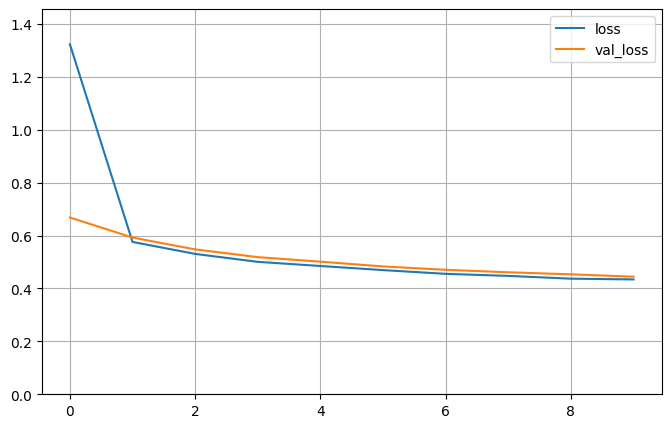

In [6]:
def plot_learning_curves(history_dict):
    pd.DataFrame(history_dict).plot(figsize=(8, 5))
    plt.grid(True)
    # Adjust ylim if necessary, it was (0,1) which might be too restrictive for MSE loss
    plt.gca().set_ylim(0, max(1, pd.DataFrame(history_dict)['loss'].max() * 1.1)) # Auto-adjust or set a reasonable upper bound
    plt.show()

plot_learning_curves(history.history_)

In [7]:
param_distribution = {
    "hidden_layers": [1, 2, 3, 4],
    "layer_size": [5, 10, 20, 30],
    "learning_rate": [1e-4, 5e-4, 1e-3, 5e-3, 1e-2], # Adjusted 5e-5 to 5e-4 for a more common range
}

from sklearn.model_selection import RandomizedSearchCV

# Re-initialize KerasRegressor for RandomizedSearchCV,
# so it doesn't use the one already fit in the previous cell.
# Pass any arguments that are NOT being tuned to the constructor.
# The `input_shape` needs to be available to `build_model`
# `KerasRegressor` will pass a `model__` prefixed param like `model__hidden_layers` as `hidden_layers` to `build_model`.
# We need to ensure `input_shape` is correctly passed.
# One way is to set it as a fixed parameter in the KerasRegressor constructor if it's not tuned.
# If `build_model` requires `input_shape` and it's not a hyperparameter to tune,
# ensure `KerasRegressor` can provide it.
# In scikeras, any **kwargs passed to KerasRegressor constructor that are not its own params
# are passed to the model building function if they are accepted by it.

# Define the search model without default values for tuned parameters
# as RandomizedSearchCV will provide them.
search_sklearn_model = KerasRegressor(
    model=lambda **kwargs: build_model(input_shape=x_train_scaled.shape[1:], **kwargs),
    verbose=0 # Keep output clean
)

random_search_cv = RandomizedSearchCV(
    search_sklearn_model,
    param_distribution,
    cv=3,      # Add cv for cross-validation
)

random_search_cv.fit(
    x_train_scaled, y_train,
    # epochs=5, # This is now a fit param for the *searcher*, not the model directly here for scikeras
    # validation_data=(x_valid_scaled, y_valid), # CV handles validation
    callbacks=callbacks # Pass callbacks here, scikeras will use them
)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [ ]:
print(random_search_cv.best_params_)
print(random_search_cv.best_score_)
print(random_search_cv.best_estimator_)

# print(grid_search_cv.best_params_)
# print(grid_search_cv.best_score_)
# print(grid_search_cv.best_estimator_)

In [ ]:
model = random_search_cv.best_estimator_.model
model.evaluate(x_test_scaled, y_test)

# model = grid_search_cv.best_estimator_.model
# model.evaluate(x_test_scaled, y_test)